In [67]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [68]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from clonalg.model.clonalg_classification import ClassificationClonalg

In [69]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

In [70]:
X = mnist.data
y = mnist.target.astype(int)

In [71]:
n = 10000
X, _, y, _ = train_test_split(X, y, train_size=n, stratify=y, random_state=42)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [106]:
classifier = ClassificationClonalg(
    n_classes=10,
    population_size=150,
    clone_factor=0.1,
    n_select=20,
    n_replace=25,
    n_generations=20,
    memory_size=40,
    rho=6.5,
    bounds=(0, 1)
)

In [107]:
classifier.fit(X_train, y_train)

100%|██████████| 10/10 [03:26<00:00, 20.70s/it]


In [108]:
predictions = classifier.predict_batch(X_test, k=3)

In [109]:
target_names = [str(i) for i in range(10)]
print(classification_report(y_test, predictions, target_names=target_names, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       191
           1       0.92      1.00      0.96       226
           2       0.96      0.93      0.94       215
           3       0.92      0.91      0.91       202
           4       0.96      0.86      0.91       206
           5       0.88      0.90      0.89       168
           6       0.95      0.95      0.95       196
           7       0.93      0.88      0.91       185
           8       0.91      0.90      0.91       206
           9       0.84      0.93      0.88       205

    accuracy                           0.92      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.93      0.92      0.92      2000



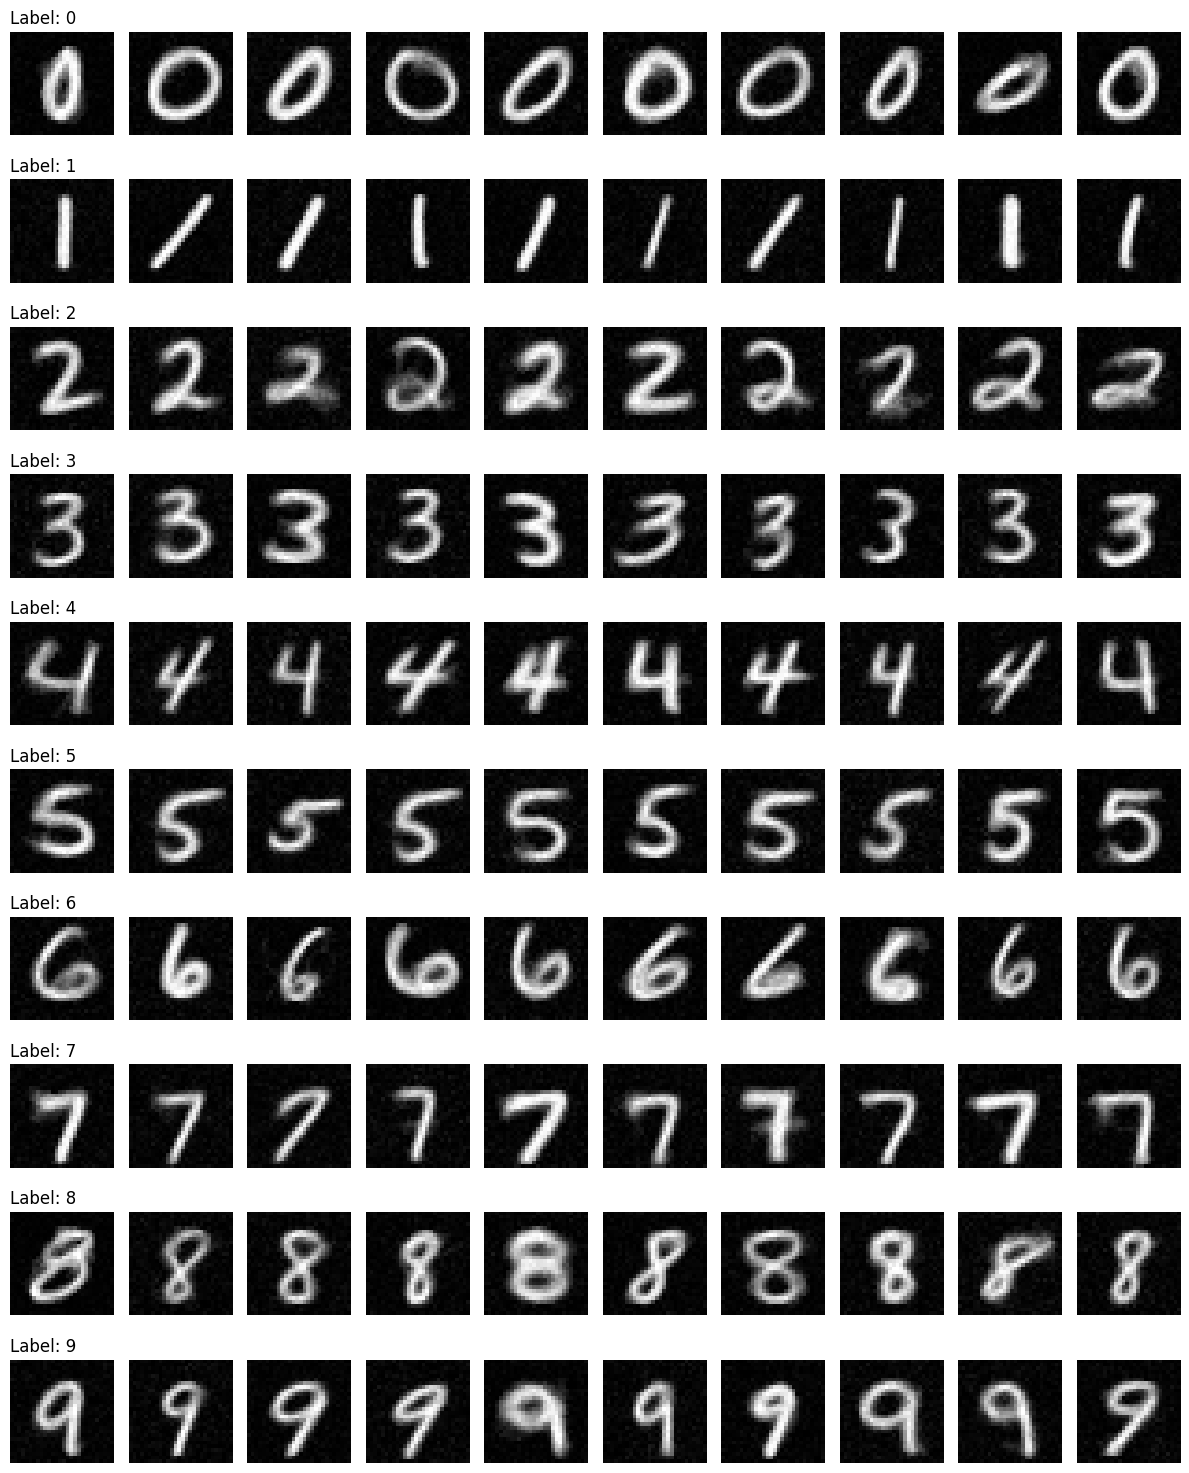

In [110]:
import matplotlib.pyplot as plt

IMG_SHAPE = (28, 28) 
N_CELLS_TO_SHOW = 10

fig, axes = plt.subplots(
    classifier.n_classes, 
    N_CELLS_TO_SHOW, 
    figsize=(12, 1.5 * classifier.n_classes)
)

for label in range(classifier.n_classes):
    memory_matrix = classifier.models[label]
    
    for i in range(N_CELLS_TO_SHOW):
        ax = axes[label, i]
        if i < len(memory_matrix):
            img = memory_matrix[i].reshape(IMG_SHAPE)
            ax.imshow(img, cmap='gray')
        
        ax.axis('off')
        
        if i == 0:
            ax.set_title(f"Label: {label}", fontsize=12, loc='left')

plt.tight_layout()
plt.show()